## analysing enso characteristics and its changes in access stabilised runs

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
import cmocean

In [4]:
from scipy import stats

In [5]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 14
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [6]:
def plot_decorator():
    plt.minorticks_on()
    plt.tick_params(which='minor', axis='x', bottom=False)
    plt.grid(alpha=0.1)

In [7]:
### Functions needed for the analysis

In [8]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
from matplotlib.colors import LogNorm as LM
import matplotlib.patches as mpatches

In [9]:
def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 14, 'color': 'k'}
    gl.ylabel_style = {'size': 14, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], draw_winds=False, u_wnd=[], v_wnd=[], wind_scale=20, draw_contour=False, contour_data=[], contour_levels=[], contour_colors='gray', nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.Robinson(central_longitude=160)):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':proj})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
        # ax.set_aspect('auto')
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i], fontsize=16)
        if draw_winds:
            axlist[i].quiver(x[::3, ::3], y[::3, ::3], u_wnd[i].to_numpy()[::3, ::3], v_wnd[i].to_numpy()[::3, ::3], scale=wind_scale, color='k', transform=ccrs.PlateCarree())
        if draw_contour:
            axlist[i].contour(x, y, contour_data[i], cmap = None, levels=contour_levels, colors=contour_colors, transform = ccrs.PlateCarree(central_longitude=0))
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':16})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            # axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
            #                                 facecolor='none', edgecolor='k',
            #                                 transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, 60], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
            # axlist[i].add_patch(mpatches.Rectangle(xy=[140, -80], width=150, height=20,
            #                                             facecolor='none', edgecolor='tab:green', lw=1.5,
            #                                             transform=ccrs.PlateCarree()))
        if add_patch_extra:
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, 20], width=60, height=20,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[210, -40], width=60, height=30,
                                                        facecolor='none', edgecolor='k', lw=1.5,
                                                        transform=ccrs.PlateCarree()))
                    
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = cbar_orientation, shrink=0.8, aspect = 45, pad = 0.05, label = cbar_label)

In [10]:
from functions import preproc_funcs as funcs

In [11]:
from functions import xr_lowess

In [12]:
#### import data

In [13]:
ts_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_ts.nc', use_cftime=True).ts
pr_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_pr.nc', use_cftime=True).pr*86400*30

In [14]:
tauu_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_tauu_original.nc', use_cftime=True).tauu
tcda_trans = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_tcda_original.nc', use_cftime=True).tcda

In [15]:
ts_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable.nc', use_cftime=True).ts
pr_stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_pr.nc', use_cftime=True).pr*86400*30

In [16]:
pr_trans_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_pr_original.nc', use_cftime=True).pr*86400*30

In [17]:
pr_stable_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_pr_original.nc', use_cftime=True).pr*86400*30

In [18]:
psl_stable_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_psl_original.nc', use_cftime=True).psl

In [19]:
tauu_stable_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_tauu_original.nc', use_cftime=True).tauu
tcda_stable_noanom = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_tcda_original.nc', use_cftime=True).tcda

### analysis

In [20]:
weights_model = np.cos(np.deg2rad(ts_trans.lat))
weights_model.name='weights'
weights_model

<xarray.DataArray 'weights' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y
    bounds:         lat_bnds

In [21]:
def time_series_plot(da, type = 'trans', model_identifier='B2045', **kwargs):
    da_detrend = funcs.detrend_rolling_window(da, window_size=30)
    da = da.where(da_detrend < 4*da_detrend.std('time')).isel(time = slice(1, -1))
    if type == 'trans':
        plt.plot(da.time.dt.year, da.quantile(0.5, 'model'), lw=2.0, **kwargs)
        plt.fill_between(da.time.dt.year, da.quantile(0.1, 'model'), da.quantile(0.9, 'model'), color=(kwargs['color']), alpha=0.2)
    else:
        plt.plot(da.time.dt.year, da.sel(model = model_identifier), **kwargs)

In [22]:
import seaborn as sns

In [23]:
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2030'), label='B2030', color='gold')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2035'), label='B2035', color='tab:orange')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2040'), label='B2040', color='red')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2045'), label='B2045', color='tab:red')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2050'), label='B2050', color='darkred')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2055'), label='B2055', color='maroon')
# # plt.plot(gmst_stable.time.dt.year, gmst_stable.sel(model = 'B2060'), label='B2060', color='tab:brown')


# time_series_plot(gmst_stable, type='stable', model_identifier='B2030', label='B2030', color='gold')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2035', label='B2035', color='tab:orange')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2040', label='B2040', color='red')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2045', label='B2045', color='tab:red')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2050', label='B2050', color='darkred')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2055', label='B2055', color='maroon')
# time_series_plot(gmst_stable, type='stable', model_identifier='B2060', label='B2060', color='tab:brown')
# time_series_plot(gmst_trans.sel(time = slice('1850', '2100')), color='k', label='ssp585')
# plt.legend(frameon=False, fontsize=10)
# plt.ylabel('Temperature anomaly (deg.C)')
# plt.xlabel('Year')
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, which='minor', axis='x')
# plt.grid(alpha=0.1, ls='--')

In [24]:
def rolling_window_smoothing(da, window_size=30):
    pad_size=window_size//2
    padded_data = da.pad(time=(pad_size, pad_size), mode='edge')
    smoothed_data = padded_data.rolling(time=window_size, center=True).mean('time').isel(time = slice(int(window_size/2),-int(window_size/2)))
    return smoothed_data

In [25]:
def rolling_window_std(da, window_size=30):
    pad_size=window_size//2
    padded_data = da.pad(time=(pad_size, pad_size), mode='edge')
    std_data = padded_data.rolling(time=window_size, center=True).std('time').isel(time = slice(int(window_size/2),-int(window_size/2)))
    return std_data

In [26]:
def additional_sampling_stabilisation(da):
    i = 100
    da_list = []
    while i <= 970:
        sample_da = da.isel(time = slice(i,i+30)).mean('time')
        da_list.append(sample_da)
        i += 30
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, 30, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


def additional_sampling_stabilisation_nomeans(da):
    i = 100
    da_list = []
    while i <= 970:
        sample_da = da.isel(time = slice(i,i+30))
        da_list.append(sample_da)
        i += 30
    print('Done')
    out_da = xr.concat(da_list, dim=np.arange(0, 30, 1))
    if 'model' in out_da.coords:
        return out_da.drop('model').rename(dict(concat_dim='model'))
    else:
        return out_da.rename(dict(concat_dim='model'))


In [27]:
additional_sampling_stabilisation(ts_stable.sel(model = 'B2060').sel(time = slice('2060', '3060')))

Done


<xarray.DataArray 'ts' (model: 30, lat: 120, lon: 240)>
array([[[2.4848008, 2.499285 , 2.509263 , ..., 2.4513109, 2.4605186,
         2.469903 ],
        [3.0353456, 3.0525122, 3.0539315, ..., 3.0162952, 3.0179093,
         3.0187464],
        [3.207218 , 3.250495 , 3.259698 , ..., 3.13864  , 3.1494024,
         3.1609008],
        ...,
        [9.891796 , 9.883352 , 9.872474 , ..., 9.927802 , 9.914163 ,
         9.903436 ],
        [9.95581  , 9.952554 , 9.9563265, ..., 9.967885 , 9.968581 ,
         9.965831 ],
        [9.853863 , 9.851009 , 9.850066 , ..., 9.856306 , 9.855132 ,
         9.854875 ]],

       [[2.643598 , 2.659482 , 2.6704895, ..., 2.6071508, 2.6173532,
         2.6277318],
        [3.1196055, 3.1399114, 3.143952 , ..., 3.0924897, 3.0963807,
         3.0998638],
        [3.244066 , 3.2895112, 3.3003738, ..., 3.1658893, 3.1806273,
         3.1957285],
...
        [8.762092 , 8.759847 , 8.777656 , ..., 8.77207  , 8.76894  ,
         8.769333 ],
        [9.049874 , 9.047938 , 9.053824 , ..., 9.042385 , 9.047978 ,
         9.050641 ],
        [9.176661 , 9.17254  , 9.170953 , ..., 9.178278 , 9.17728  ,
         9.177874 ]],

       [[4.458312 , 4.473111 , 4.483526 , ..., 4.4235454, 4.43306  ,
         4.443047 ],
        [4.969563 , 4.9880767, 4.990706 , ..., 4.948608 , 4.950284 ,
         4.9520864],
        [5.205641 , 5.2474904, 5.2540154, ..., 5.145131 , 5.154592 ,
         5.1636653],
        ...,
        [8.408775 , 8.418749 , 8.434335 , ..., 8.384654 , 8.391219 ,
         8.403881 ],
        [8.719107 , 8.71959  , 8.725207 , ..., 8.706928 , 8.710342 ,
         8.714172 ],
        [8.848322 , 8.844766 , 8.8436775, ..., 8.8507805, 8.849561 ,
         8.849274 ]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.0 1.5 3.0 4.5 6.0 ... 352.5 354.0 355.5 357.0 358.5
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
  * model    (model) int64 0 1 2 3 4 5 6 7 8 9 ... 20 21 22 23 24 25 26 27 28 29

In [28]:
import glob

In [29]:
# files = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/ts/gn/latest/*.nc'))
# ts_pic = xr.open_mfdataset(files)

In [30]:
# files = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/pr/gn/latest/*.nc'))
# pr_pic = xr.open_mfdataset(files)

In [31]:
# import xesmf as xe

In [32]:
# ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
# ds_out

In [33]:
# regridder = xe.Regridder(ts_pic, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)

In [34]:
# ts_pic_loaded = regridder(funcs.calc_anom(ts_pic.ts, ts_pic.ts).resample(time = 'AS-JUN').mean('time')).load()#.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).mean(('lat', 'lon')).load()
# ts_pic_loaded

In [35]:
# pr_pic_loaded = regridder(funcs.calc_anom(pr_pic.pr, pr_pic.pr).resample(time = 'AS-JUN').mean('time')).load()#.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).mean(('lat', 'lon')).load()
# pr_pic_loaded

In [36]:
# ts_pic_loaded.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/ts_pic_loaded.nc')
# pr_pic_loaded.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/pr_pic_loaded.nc')

In [77]:
ts_pic_loaded = xr.open_dataset('/g/data/if69/as8561/data/ts_pic.nc').sortby('model').isel(model=1).ts
pr_pic_loaded = xr.open_dataset('/g/data/if69/as8561/data/pr_pic.nc').sortby('model').isel(model=1).ts

In [89]:
nino34_pic = funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon'))

Text(0, 0.5, 'Nino34 index (K)')

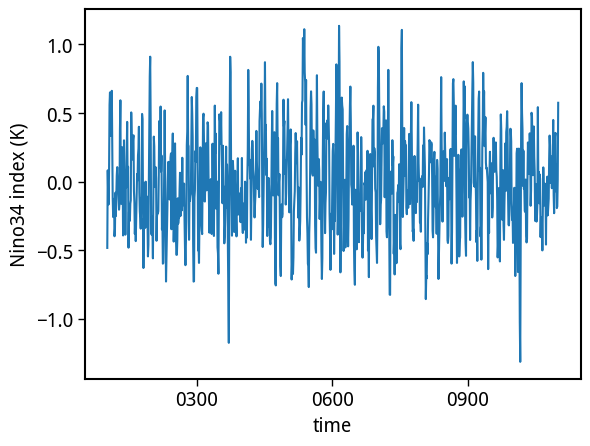

In [90]:
nino34_pic.rolling(time = 3, center=True).mean('time').plot()
plt.ylabel('Nino34 index (K)')

In [91]:
nino3_pic = funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon'))
nino4_pic = funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat = slice(-5, 5), lon = slice(160, -150+360)).weighted(weights_model).mean(('lat', 'lon'))

In [95]:
sst_grad_pic = (funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat=slice(-5,5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - funcs.calc_anom(ts_pic_loaded, ts_pic_loaded).sel(lat=slice(-5,5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon')))
sst_grad_pic

<xarray.DataArray 'ts' (time: 2001)>
array([ 0.44843263, -0.50798935, -0.07014902, ...,         nan,
               nan,         nan])
Coordinates:
  * time     (time) object 0100-12-31 00:00:00 ... 2100-12-31 00:00:00
    model    (time) <U13 'ACCESS-ESM1-5' 'ACCESS-ESM1-5' ... 'ACCESS-ESM1-5'
    month    (time) int64 12 12 12 12 12 12 12 12 12 ... 12 12 12 12 12 12 12 12

In [96]:
import seaborn as sns

Text(0.5, 0, 'Time')

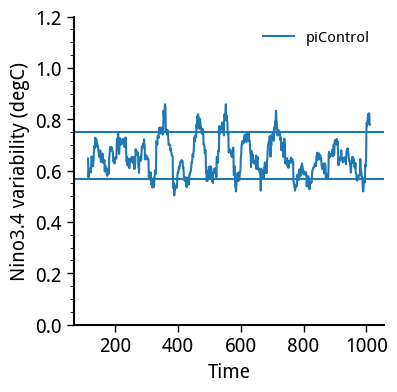

In [97]:
plt.figure(figsize=(4,4))
rolling_std_picontrol = rolling_window_std(funcs.detrend_separate_check(nino34_pic, period=15, dim='time'), window_size=30).isel(time = slice(15, -15))
plt.plot(rolling_std_picontrol.time.dt.year, rolling_std_picontrol, label='piControl')
plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(0, 1.2)
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11)
plt.ylabel('Nino3.4 variability (degC)')
plt.xlabel('Time')


Text(0.5, 0, 'Time')

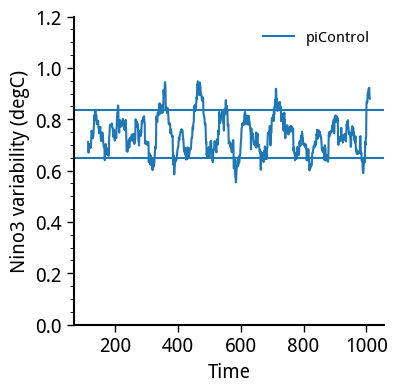

In [98]:
plt.figure(figsize=(4,4))
rolling_std_picontrol = rolling_window_std(funcs.detrend_separate_check(nino3_pic, period=15, dim='time'), window_size=30).isel(time = slice(15, -15))
plt.plot(rolling_std_picontrol.time.dt.year, rolling_std_picontrol, label='piControl')
plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(0, 1.2)
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11)
plt.ylabel('Nino3 variability (degC)')
plt.xlabel('Time')


Text(0.5, 0, 'Time')

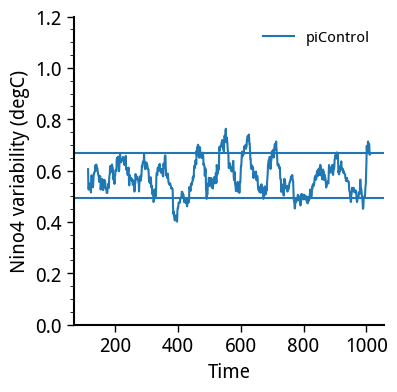

In [99]:
plt.figure(figsize=(4,4))
rolling_std_picontrol = rolling_window_std(funcs.detrend_separate_check(nino4_pic, period=15, dim='time'), window_size=30).isel(time = slice(15, -15))
plt.plot(rolling_std_picontrol.time.dt.year, rolling_std_picontrol, label='piControl')
plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(0, 1.2)
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11)
plt.ylabel('Nino4 variability (degC)')
plt.xlabel('Time')


In [100]:
nino34_trans = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
print('done')
nino34_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(-170+360, -120+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)

done


In [101]:
nino3_trans = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
nino3_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(-150+360, -90+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)

In [102]:
nino4_trans = funcs.detrend_rolling_window(ts_trans.sel(lat = slice(-5, 5), lon = slice(160, -150+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)
nino4_stable = funcs.detrend_rolling_window(ts_stable.sel(lat = slice(-5, 5), lon = slice(160, -150+360)).weighted(weights_model).mean(('lat', 'lon')), window_size=15)

In [103]:
nino34_mag_trans = rolling_window_std(nino34_trans, window_size=30).isel(time = slice(15, -15))
nino34_mag_stable = rolling_window_std(nino34_stable, window_size=30).isel(time = slice(15, -15))

In [104]:
nino3_mag_trans = rolling_window_std(nino3_trans, window_size=30).isel(time = slice(15, -15))
nino3_mag_stable = rolling_window_std(nino3_stable, window_size=30).isel(time = slice(15, -15))

In [105]:
nino4_mag_trans = rolling_window_std(nino4_trans, window_size=30).isel(time = slice(15, -15))
nino4_mag_stable = rolling_window_std(nino4_stable, window_size=30).isel(time = slice(15, -15))

Text(0.5, 0, 'Year')

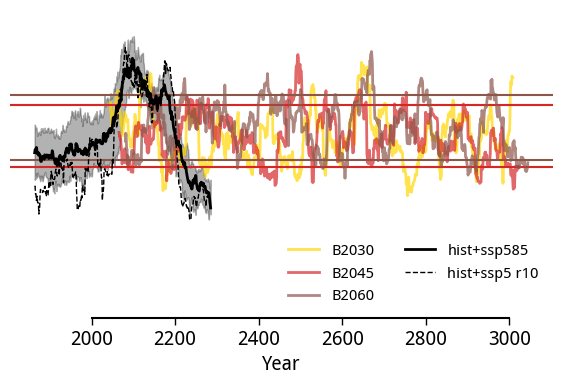

In [106]:
plt.figure(figsize=(7,4))

plt.plot(nino34_mag_stable.time.dt.year, nino34_mag_stable.sel(model = 'B2030'), color='gold', lw=2.0, alpha=0.7, label='B2030')
plt.axhline(nino34_mag_stable.sel(model='B2030').quantile(0.1, dim='time'), color='gold')
plt.axhline(nino34_mag_stable.sel(model='B2030').quantile(0.9, dim='time'), color='gold')
plt.plot(nino34_mag_stable.time.dt.year, nino34_mag_stable.sel(model = 'B2045'), color='tab:red', lw=2.0, alpha=0.7, label='B2045')
plt.axhline(nino34_mag_stable.sel(model='B2045').quantile(0.1, dim='time'), color='tab:red')
plt.axhline(nino34_mag_stable.sel(model='B2045').quantile(0.9, dim='time'), color='tab:red')
plt.plot(nino34_mag_stable.time.dt.year, nino34_mag_stable.sel(model = 'B2060'), color='tab:brown', lw=2.0, alpha=0.7, label='B2060')
plt.axhline(nino34_mag_stable.sel(model='B2060').quantile(0.1, dim='time'), color='tab:brown')
plt.axhline(nino34_mag_stable.sel(model='B2060').quantile(0.9, dim='time'), color='tab:brown')

plt.plot(nino34_mag_trans.time.dt.year, nino34_mag_trans.quantile(0.5, 'model'), color='k', lw=2.0, label='hist+ssp585')
plt.plot(nino34_mag_trans.time.dt.year, nino34_mag_trans.sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(nino34_mag_trans.time.dt.year, nino34_mag_trans.quantile(0.1, 'model'), nino34_mag_trans.quantile(0.9, 'model'), color='k', alpha=0.3)
# plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(0, 1.2)
sns.despine(left=True, trim=True)
plt.yticks([])
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11, loc='lower right', ncol=2)
# plt.ylabel('ENSO variability (degC)')
plt.xlabel('Year')


Text(0.5, 0, 'Year')

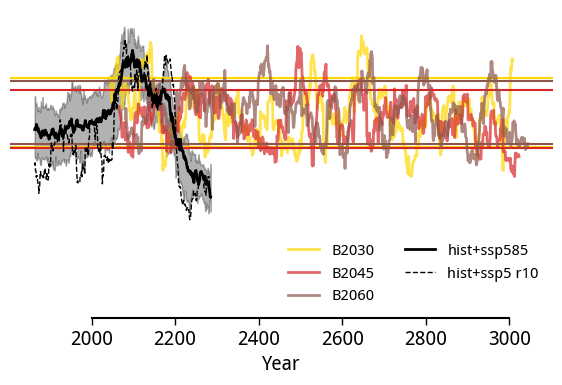

In [107]:
plt.figure(figsize=(7,4))

plt.plot(nino3_mag_stable.time.dt.year, nino3_mag_stable.sel(model = 'B2030'), color='gold', lw=2.0, alpha=0.7, label='B2030')
plt.axhline(nino3_mag_stable.sel(model='B2030').quantile(0.1, dim='time'), color='gold')
plt.axhline(nino3_mag_stable.sel(model='B2030').quantile(0.9, dim='time'), color='gold')
plt.plot(nino3_mag_stable.time.dt.year, nino3_mag_stable.sel(model = 'B2045'), color='tab:red', lw=2.0, alpha=0.7, label='B2045')
plt.axhline(nino3_mag_stable.sel(model='B2045').quantile(0.1, dim='time'), color='tab:red')
plt.axhline(nino3_mag_stable.sel(model='B2045').quantile(0.9, dim='time'), color='tab:red')
plt.plot(nino3_mag_stable.time.dt.year, nino3_mag_stable.sel(model = 'B2060'), color='tab:brown', lw=2.0, alpha=0.7, label='B2060')
plt.axhline(nino3_mag_stable.sel(model='B2060').quantile(0.1, dim='time'), color='tab:brown')
plt.axhline(nino3_mag_stable.sel(model='B2060').quantile(0.9, dim='time'), color='tab:brown')

plt.plot(nino3_mag_trans.time.dt.year, nino3_mag_trans.quantile(0.5, 'model'), color='k', lw=2.0, label='hist+ssp585')
plt.plot(nino3_mag_trans.time.dt.year, nino3_mag_trans.sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(nino3_mag_trans.time.dt.year, nino3_mag_trans.quantile(0.1, 'model'), nino3_mag_trans.quantile(0.9, 'model'), color='k', alpha=0.3)
# plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(0, 1.2)
sns.despine(left=True, trim=True)
plt.yticks([])
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11, loc='lower right', ncol=2)
# plt.ylabel('ENSO variability (degC)')
plt.xlabel('Year')


Text(0.5, 0, 'Year')

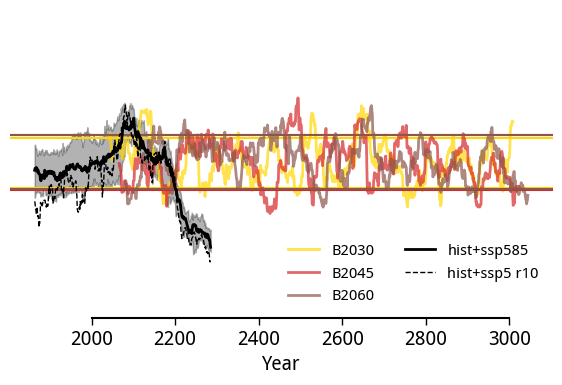

In [108]:
plt.figure(figsize=(7,4))

plt.plot(nino4_mag_stable.time.dt.year, nino4_mag_stable.sel(model = 'B2030'), color='gold', lw=2.0, alpha=0.7, label='B2030')
plt.axhline(nino4_mag_stable.sel(model='B2030').quantile(0.1, dim='time'), color='gold')
plt.axhline(nino4_mag_stable.sel(model='B2030').quantile(0.9, dim='time'), color='gold')
plt.plot(nino4_mag_stable.time.dt.year, nino4_mag_stable.sel(model = 'B2045'), color='tab:red', lw=2.0, alpha=0.7, label='B2045')
plt.axhline(nino4_mag_stable.sel(model='B2045').quantile(0.1, dim='time'), color='tab:red')
plt.axhline(nino4_mag_stable.sel(model='B2045').quantile(0.9, dim='time'), color='tab:red')
plt.plot(nino4_mag_stable.time.dt.year, nino4_mag_stable.sel(model = 'B2060'), color='tab:brown', lw=2.0, alpha=0.7, label='B2060')
plt.axhline(nino4_mag_stable.sel(model='B2060').quantile(0.1, dim='time'), color='tab:brown')
plt.axhline(nino4_mag_stable.sel(model='B2060').quantile(0.9, dim='time'), color='tab:brown')

plt.plot(nino4_mag_trans.time.dt.year, nino4_mag_trans.quantile(0.5, 'model'), color='k', lw=2.0, label='hist+ssp585')
plt.plot(nino4_mag_trans.time.dt.year, nino4_mag_trans.sel(model='ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp5 r10')
plt.fill_between(nino4_mag_trans.time.dt.year, nino4_mag_trans.quantile(0.1, 'model'), nino4_mag_trans.quantile(0.9, 'model'), color='k', alpha=0.3)
# plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(0, 1.2)
sns.despine(left=True, trim=True)
plt.yticks([])
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11, loc='lower right', ncol=2)
# plt.ylabel('ENSO variability (degC)')
plt.xlabel('Year')


Text(0.5, 0, 'ENSO Magnitude (degC)')

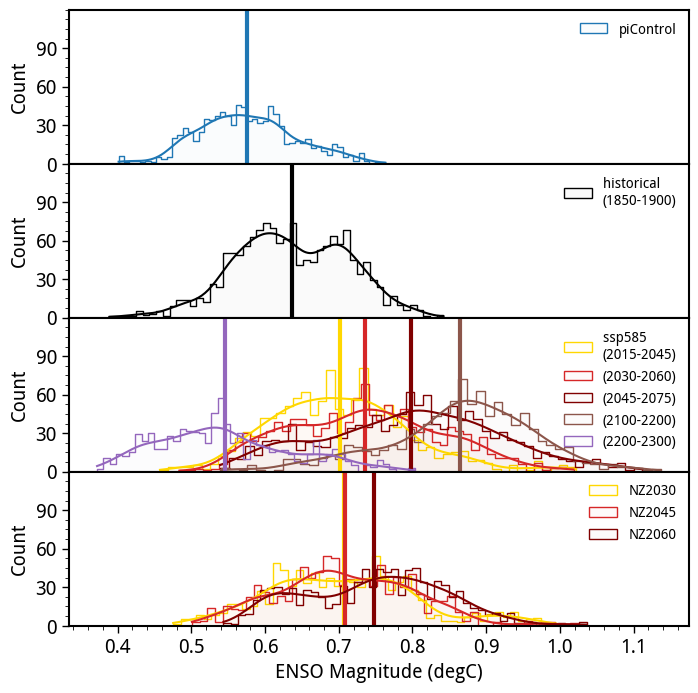

In [109]:
fig, axarr = plt.subplots(nrows=4, ncols=1, figsize=(8,8), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()

sns.histplot(rolling_std_picontrol, kde=True, color='tab:blue', alpha=0.02, element='step', bins=50, ax=axlist[0], label='piControl')
axlist[0].axvline(rolling_std_picontrol.mean('time'), color='tab:blue', lw=3.0)

sns.histplot(np.ravel(nino34_mag_trans.sel(time = slice('1850', '1900'))), color='k', kde=True, alpha=0.02, element='step', bins=50, ax=axlist[1], label='historical \n(1850-1900)')
axlist[1].axvline(np.mean(np.ravel(nino34_mag_trans.sel(time = slice('1850', '1900')))), color='k', lw=3.0)

sns.histplot(np.ravel(nino34_mag_trans.sel(time = slice('2015', '2045'))), color='gold', kde=True, alpha=0.02, element='step', bins=50, ax=axlist[2], label='ssp585 \n(2015-2045)')
axlist[2].axvline(np.mean(np.ravel(nino34_mag_trans.sel(time = slice('2015', '2045')))), color='gold', lw=3.0)
sns.histplot(np.ravel(nino34_mag_trans.sel(time = slice('2030', '2060'))), color='tab:red', kde=True, alpha=0.02, element='step', bins=50, ax=axlist[2], label='(2030-2060)')
axlist[2].axvline(np.mean(np.ravel(nino34_mag_trans.sel(time = slice('2030', '2060')))), color='tab:red', lw=3.0)
sns.histplot(np.ravel(nino34_mag_trans.sel(time = slice('2045', '2075'))), color='maroon', kde=True, alpha=0.02, element='step', bins=50, ax=axlist[2], label='(2045-2075)')
axlist[2].axvline(np.mean(np.ravel(nino34_mag_trans.sel(time = slice('2045', '2075')))), color='maroon', lw=3.0)
sns.histplot(np.ravel(nino34_mag_trans.sel(time = slice('2100', '2200'))), color='tab:brown', kde=True, alpha=0.02, element='step', bins=50, ax=axlist[2], label='(2100-2200)')
axlist[2].axvline(np.nanmean(np.ravel(nino34_mag_trans.sel(time = slice('2100', '2200')))), color='tab:brown', lw=3.0)
sns.histplot(np.ravel(nino34_mag_trans.sel(time = slice('2200', '2300'))), color='tab:purple', kde=True, alpha=0.02, element='step', bins=50, ax=axlist[2], label='(2200-2300)')
axlist[2].axvline(np.nanmean(np.ravel(nino34_mag_trans.sel(time = slice('2200', '2300')))), color='tab:purple', lw=3.0)

sns.histplot(nino34_mag_stable.sel(model='B2030'), color='gold', kde=True, alpha=0.02, element='step', bins=50, ax=axlist[3], label='NZ2030')
axlist[3].axvline(nino34_mag_stable.sel(model = 'B2030').mean('time'), color='gold', lw=3.0)
sns.histplot(nino34_mag_stable.sel(model='B2045'), color='tab:red', kde=True, alpha=0.02, element='step', bins=50, ax=axlist[3], label='NZ2045')
axlist[3].axvline(nino34_mag_stable.sel(model = 'B2045').mean('time'), color='tab:red', lw=3.0)
sns.histplot(nino34_mag_stable.sel(model='B2060'), color='maroon', kde=True, alpha=0.02, element='step', bins=50, ax=axlist[3], label='NZ2060')
axlist[3].axvline(nino34_mag_stable.sel(model = 'B2060').mean('time'), color='maroon', lw=3.0)

for j in range(len(axlist)):
#     # axlist[j].
#     pass
    axlist[j].legend(frameon=False, fontsize=10, loc='upper right')

# sns.despine(trim=True, bottom=False)
# sns.despine()
# plt.xticks([])
plt.ylim(0, 120)
# plt.ylim(0, 0.9)
plt.gca().set_yticks(np.arange(0, 120, 30))
plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.minorticks_on()
plt.xlabel('ENSO Magnitude (degC)')

Text(0.5, 0, 'Time')

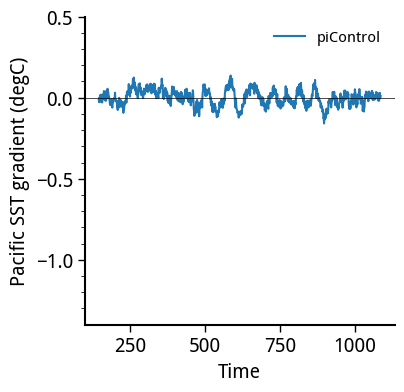

In [110]:
plt.figure(figsize=(4,4))
rolling_sst_grad_pic = rolling_window_smoothing(sst_grad_pic, window_size=30).isel(time = slice(15, -15))
plt.plot(rolling_sst_grad_pic.time.dt.year[30:], rolling_sst_grad_pic[30:], label='piControl')
# plt.axhline(rolling_sstg_picontrol[30:].quantile(0.5, dim='time'))
plt.axhline(0.0, color='k', lw=0.5)
plt.ylim(-1.4, 0.5)
sns.despine()
plt.minorticks_on()
plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11)
plt.ylabel('Pacific SST gradient (degC)')
plt.xlabel('Time')


In [111]:
sst_grad_trans = ts_trans.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - ts_trans.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon'))

sst_grad_stable = ts_stable.sel(lat = slice(-5, 5), lon = slice(140, 170)).weighted(weights_model).mean(('lat', 'lon')) - ts_stable.sel(lat = slice(-5, 5), lon = slice(190, 270)).weighted(weights_model).mean(('lat', 'lon'))

In [112]:
rolling_sst_grad_trans = (rolling_window_smoothing(sst_grad_trans, window_size=30)).isel(time = slice(15, -15))
rolling_sst_grad_stable = (rolling_window_smoothing(sst_grad_stable, window_size=30)).isel(time = slice(15, -15))

Text(0.5, 0, 'Year')

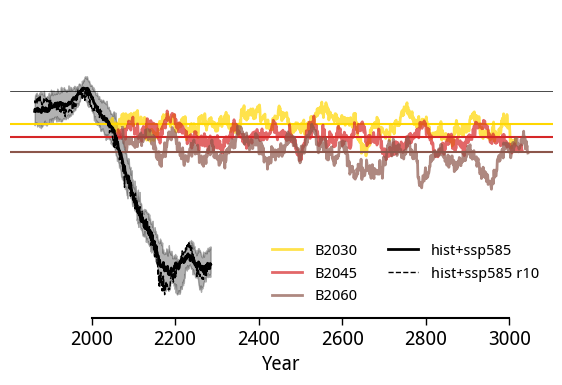

In [113]:
plt.figure(figsize=(7,4))

plt.plot(rolling_sst_grad_stable.time.dt.year, rolling_sst_grad_stable.sel(model = 'B2030'), color='gold', lw=2.0, alpha=0.7, label='B2030')
plt.axhline(rolling_sst_grad_stable.sel(model='B2030').quantile(0.5, dim='time'), color='gold')
plt.plot(rolling_sst_grad_stable.time.dt.year, rolling_sst_grad_stable.sel(model = 'B2045'), color='tab:red', lw=2.0, alpha=0.7, label='B2045')
plt.axhline(rolling_sst_grad_stable.sel(model='B2045').quantile(0.5, dim='time'), color='tab:red')
plt.plot(rolling_sst_grad_stable.time.dt.year, rolling_sst_grad_stable.sel(model = 'B2060'), color='tab:brown', lw=2.0, alpha=0.7, label='B2060')
plt.axhline(rolling_sst_grad_stable.sel(model='B2060').quantile(0.5, dim='time'), color='tab:brown')

plt.plot(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.quantile(0.5, 'model'), color='k', lw=2.0, label='hist+ssp585')
plt.plot(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.sel(model = 'ACCESS-ESM1-5_r10i1p1f1'), color='k', ls='--', lw=1.0, label='hist+ssp585 r10')
plt.fill_between(rolling_sst_grad_trans.time.dt.year, rolling_sst_grad_trans.quantile(0.1, 'model'), rolling_sst_grad_trans.quantile(0.9, 'model'), color='k', alpha=0.3)
# plt.axhline(rolling_std_picontrol.quantile(0.1, dim='time'))
# plt.axhline(rolling_std_picontrol.quantile(0.9, dim='time'))
plt.ylim(-1.4, 0.5)
sns.despine(left=True, trim=True)
plt.yticks([])
# plt.minorticks_on()
# plt.gca().tick_params(bottom=False, axis='x', which='minor')
plt.legend(frameon=False, fontsize=11, loc='lower right', ncol=2)
plt.axhline(0.0, color='k', lw=0.5)
# plt.ylabel('ENSO variability (degC)')
plt.xlabel('Year')


Done
Done
Done
Done


Text(0.5, 0, 'Tropical Pacific SST gradient anomaly (degC)')

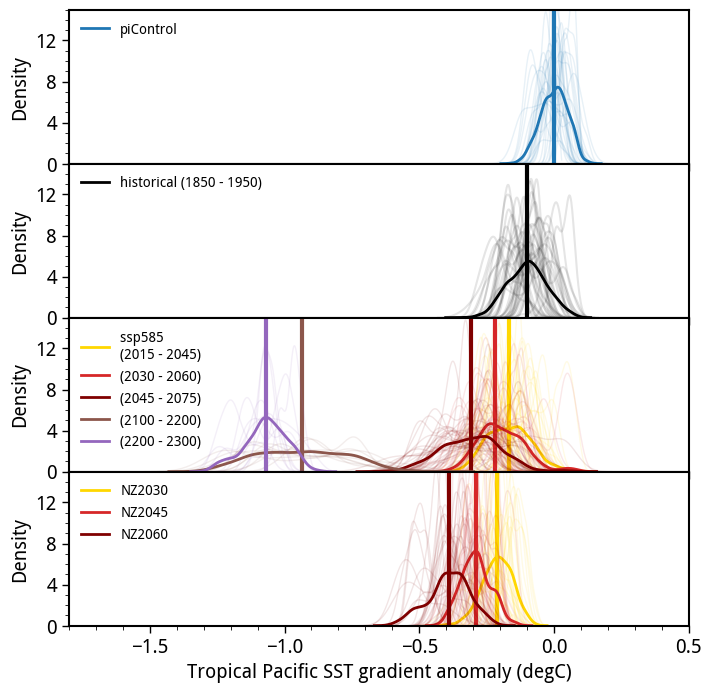

In [114]:
fig, axarr = plt.subplots(nrows=4, ncols=1, figsize=(8,8), constrained_layout=True, sharex=True, sharey=True)
axlist = axarr.flatten()

test = additional_sampling_stabilisation_nomeans(rolling_sst_grad_pic)
sns.kdeplot(test.values.flatten(), color='tab:blue', lw=2.0, label='piControl', ax=axlist[0])
axlist[0].axvline(test.mean(), color='tab:blue', lw=3.0)
for i in range(len(test.model)):
    sns.kdeplot(test.isel(model = i), color='tab:blue', alpha=0.1, lw=1.0, ax=axlist[0])

sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('1850', '1950')).values.flatten(), color='k', lw=2.0, label='historical (1850 - 1950)', ax=axlist[1])
axlist[1].axvline(rolling_sst_grad_trans.sel(time = slice('1850', '1950')).mean(), color='k', lw=3.0)
for i in range(len(rolling_sst_grad_trans.model)):
    sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('1850', '1950')).isel(model = i), color='k', alpha=0.1, ax=axlist[1])

sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2015', '2045')).values.flatten(), color='gold', lw=2.0, label='ssp585 \n(2015 - 2045)', ax=axlist[2])
axlist[2].axvline(rolling_sst_grad_trans.sel(time = slice('2015', '2045')).mean(), color='gold', lw=3.0)
for i in range(len(rolling_sst_grad_trans.model)):
    sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2015', '2045')).isel(model = i), color='gold', alpha=0.1, lw=1.0, ax=axlist[2])

sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2030', '2050')).values.flatten(), color='tab:red', lw=2.0, label='(2030 - 2060)', ax=axlist[2])
axlist[2].axvline(rolling_sst_grad_trans.sel(time = slice('2030', '2060')).mean(), color='tab:red', lw=3.0)
for i in range(len(rolling_sst_grad_trans.model)):
    sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2030', '2060')).isel(model = i), color='tab:red', alpha=0.1, lw=1.0, ax=axlist[2])

sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2045', '2075')).values.flatten(), color='maroon', lw=2.0, label='(2045 - 2075)', ax=axlist[2])
axlist[2].axvline(rolling_sst_grad_trans.sel(time = slice('2045', '2075')).mean(), color='maroon', lw=3.0)
for i in range(len(rolling_sst_grad_trans.model)):
    sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2045', '2075')).isel(model = i), color='maroon', alpha=0.1, lw=1.0, ax=axlist[2])

sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2100', '2200')).values.flatten(), color='tab:brown', lw=2.0, label='(2100 - 2200)', ax=axlist[2])
axlist[2].axvline(rolling_sst_grad_trans.sel(time = slice('2100', '2200')).mean(), color='tab:brown', lw=3.0)
for i in range(len(rolling_sst_grad_trans.model)):
    sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2100', '2200')).isel(model = i), color='tab:brown', alpha=0.1, lw=1.0, ax=axlist[2])

sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2200', '2300')).values.flatten(), color='tab:purple', lw=2.0, label='(2200 - 2300)', ax=axlist[2])
axlist[2].axvline(rolling_sst_grad_trans.sel(time = slice('2200', '2300')).mean(), color='tab:purple', lw=3.0)
for i in range(len(rolling_sst_grad_trans.model)):
    sns.kdeplot(rolling_sst_grad_trans.sel(time = slice('2200', '2300')).isel(model = i), color='tab:purple', alpha=0.1, lw=1.0, ax=axlist[2])




test = additional_sampling_stabilisation_nomeans(rolling_sst_grad_stable.sel(model = 'B2030').drop('model'))
sns.kdeplot(test.values.flatten(), color='gold', lw=2.0, label='NZ2030', ax=axlist[3])
axlist[3].axvline(test.mean(), color='gold', lw=3.0)
for i in range(len(test.model)):
    sns.kdeplot(test.isel(model = i), color='gold', alpha=0.1, lw=1.0, ax=axlist[3])

test = additional_sampling_stabilisation_nomeans(rolling_sst_grad_stable.sel(model = 'B2045').drop('model'))
sns.kdeplot(test.values.flatten(), color='tab:red', lw=2.0, label='NZ2045', ax=axlist[3])
axlist[3].axvline(test.mean(), color='tab:red', lw=3.0)
for i in range(len(test.model)):
    sns.kdeplot(test.isel(model = i), color='tab:red', alpha=0.1, lw=1.0, ax=axlist[3])

test = additional_sampling_stabilisation_nomeans(rolling_sst_grad_stable.sel(model = 'B2060').drop('model'))
sns.kdeplot(test.values.flatten(), color='maroon', lw=2.0, label='NZ2060', ax=axlist[3])
axlist[3].axvline(test.mean(), color='maroon', lw=3.0)
for i in range(len(test.model)):
    sns.kdeplot(test.isel(model = i), color='maroon', alpha=0.1, lw=1.0, ax=axlist[3])



for j in range(len(axlist)):
#     # axlist[j].
#     pass
    axlist[j].legend(frameon=False, fontsize=10, loc='upper left')

# sns.despine(trim=True, bottom=False)
# sns.despine()
# plt.xticks([])
plt.xlim(-1.8, 0.5)
plt.ylim(0, 15)
plt.gca().set_yticks(np.arange(0, 16, 4))
plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.minorticks_on()
plt.xlabel('Tropical Pacific SST gradient anomaly (degC)')

### ENSO asymmetry

In [62]:
from eofs.xarray import Eof

In [63]:
sst_obs = xr.open_dataset('/g/data/su28/MMLEAv2/observations/tos_hadisst_g025_187001-202412.nc').tos
sst_obs['time'] = pd.date_range('1870-01-01', '2025-01-01', freq='1M')
sst_obs

<xarray.DataArray 'tos' (time: 1860, lat: 72, lon: 144)>
[19284480 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 1870-01-31 1870-02-28 ... 2024-12-31
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
Attributes:
    long_name:  sea_surface_temperature
    units:      C

In [64]:
sst_obs_anom = funcs.calc_anom(sst_obs, sst_obs.sel(time = slice('1960', '1990')))
sst_obs_anom

<xarray.DataArray 'tos' (time: 1860, lat: 72, lon: 144)>
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.        ,  0.        , -0.00428287, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
  * time     (time) datetime64[ns] 1870-01-31 1870-02-28 ... 2024-12-31
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [65]:
sst_obs_annual = funcs.detrend_rolling_window(sst_obs_anom.resample(time = 'AS-JUN').mean('time'), window_size=15)
sst_obs_annual

<xarray.DataArray 'tos' (time: 156, lat: 72, lon: 144)>
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.01357383,  0.02203195,  0.02799053, ...,  0.01828675,
          0.00968474,  0.01161681],
        [ 0.00103638,  0.00028926,  0.        , ...,  0.00034729,
          0.00041796,  0.00059099],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * time     (time) datetime64[ns] 1869-06-01 1870-06-01 ... 2024-06-01

In [66]:
solver = Eof(sst_obs_annual.sel(lat = slice(-40, 40), lon = slice(100, 300), time = slice('1900', '2015')))
eofs_pic = solver.eofs(neofs=3)
pcs_pic = solver.pcs(npcs=3)
variance_pic = solver.varianceFraction(neigs=3)

In [67]:
plot_list = [(eofs_pic.isel(mode=0)*pcs_pic.isel(mode=0).std('time')),
             (eofs_pic.isel(mode=1)*pcs_pic.isel(mode=1).std('time')),
             (eofs_pic.isel(mode=2)*pcs_pic.isel(mode=2).std('time')),
             ]

In [68]:
title_list = [
    f'EOF1 ({np.round(float(variance_pic.isel(mode=0)), 4)*100})%',
    f'EOF2 ({np.round(float(variance_pic.isel(mode=1)), 4)*100})%',
    f'EOF3 ({np.round(float(variance_pic.isel(mode=2)), 4)*100})%',
]

In [69]:
label_list = [
    '',
    '',
    '',
]

In [70]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

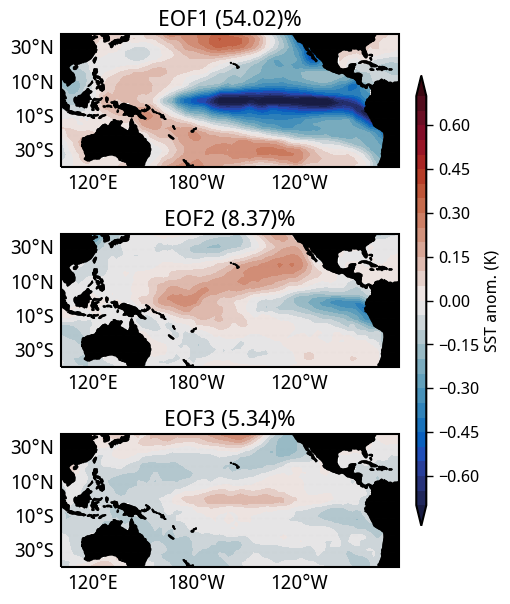

In [71]:
plot_maps(xx, yy, plot_list, title_list, label_list, cmap=cmocean.cm.balance, levels=np.arange(-0.7, 0.75, 0.05), cbar_label = 'SST anom. (K)', pval = [], nrows=3, ncols=1, figsize=(5,6), land_mask_list = [0, 1, 2], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=160))

In [72]:
pc1 = pcs_pic.isel(mode=0)/pcs_pic.isel(mode=0).std('time')
pc2 = pcs_pic.isel(mode=1)/pcs_pic.isel(mode=1).std('time')

In [73]:
e_index = (pc1 - pc2)/np.sqrt(2)
c_index = (pc1 + pc2)/np.sqrt(2)

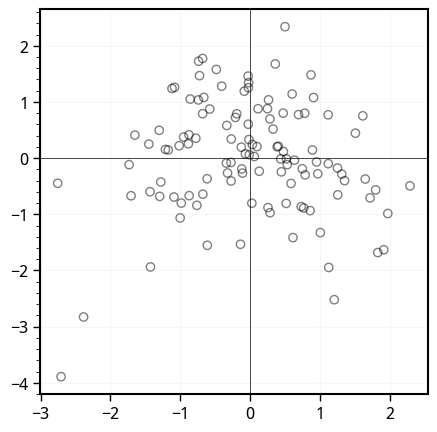

In [74]:

plt.figure(figsize=(5,5))
plt.scatter(pc1, pc2, marker='o', color='k', facecolor='None', alpha=0.5)
# plt.scatter(pc1[(e_index < -e_index.std('time') & (c_index >))], pc2[(e_index < -e_index.std('time'))], marker='o', color='tab:purple')
# plt.scatter(pc1[(e_index > e_index.std('time'))], pc2[(e_index > e_index.std('time'))], marker='o', color='maroon')
# plt.scatter(pc1[(c_index < -c_index.std('time'))], pc2[(c_index < -c_index.std('time'))], marker='o', color='tab:blue')
# plt.scatter(pc1[(c_index > c_index.std('time'))], pc2[(c_index > c_index.std('time'))], marker='o', color='tab:red')
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
plot_decorator()

In [75]:
plot_list = [sst_obs_annual.where(e_index > e_index.std('time')).mean('time'),
             sst_obs_annual.where(e_index < -e_index.std('time')).mean('time'),
             sst_obs_annual.where(c_index > c_index.std('time')).mean('time'),
             sst_obs_annual.where(c_index < -c_index.std('time')).mean('time'),
             ]

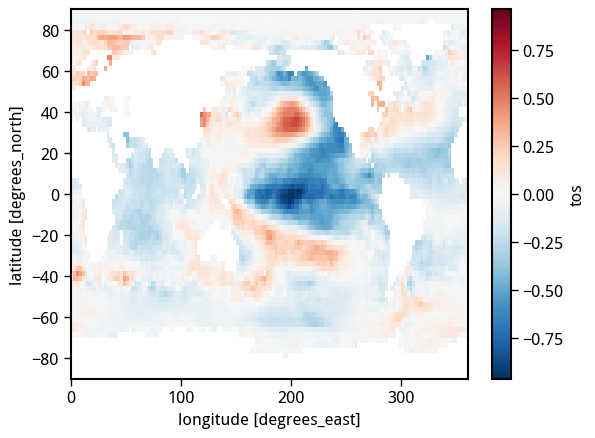

In [76]:
sst_obs_annual.where((e_index > e_index.std('time')) & (np.abs(c_index) < 0.5*c_index.std('time'))).mean('time').plot()

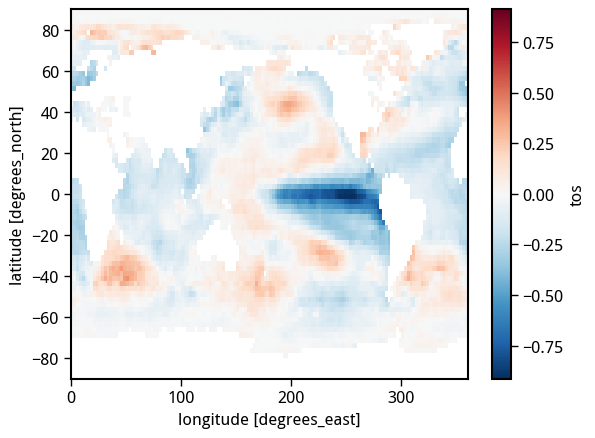

In [151]:
sst_obs_annual.where((c_index > c_index.std('time')) & (np.abs(e_index) < 0.5*e_index.std('time'))).mean('time').plot()

In [106]:
title_list = [
    'EP El Nino',
    'EP La Nina',
    'CP El Nino',
    'CP La Nina',
]

In [107]:
label_list = [
    '',
    '',
    '',
    '',
]

In [108]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

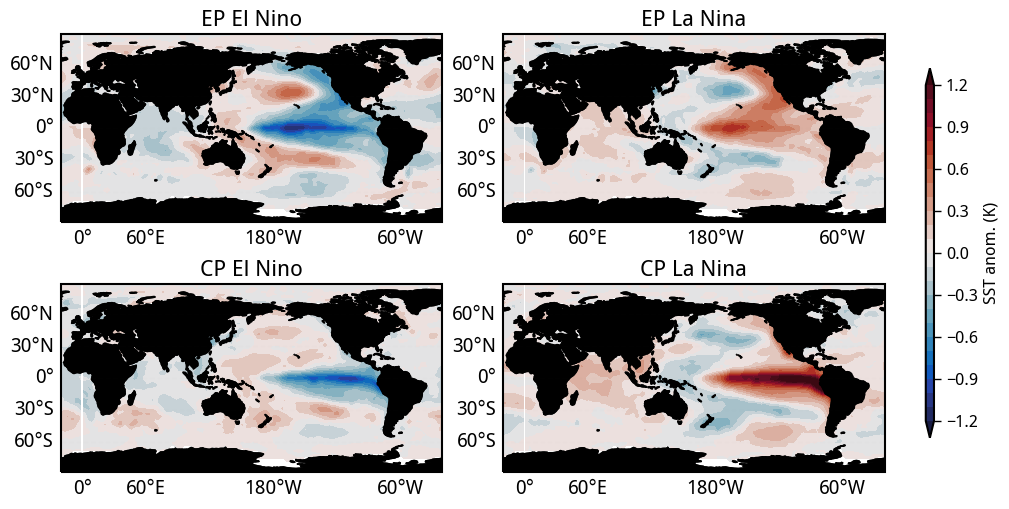

In [109]:
plot_maps(xx, yy, plot_list, title_list, label_list, cmap=cmocean.cm.balance, levels=np.arange(-1.2, 1.3, 0.1), cbar_label = 'SST anom. (K)', pval = [], nrows=2, ncols=2, figsize=(10,5), land_mask_list = [0, 1, 2, 3], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=160))

In [81]:
import regionmask

In [82]:
land_mask = regionmask.defined_regions.natural_earth_v5_0_0.land_10.mask_3D(ts_pic_loaded)
land_mask

<xarray.DataArray 'mask' (region: 1, lat: 120, lon: 240)>
array([[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])
Coordinates:
    latitude_longitude  float64 nan
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * region              (region) int64 0
    abbrevs             (region) <U3 'lnd'
    names               (region) <U4 'land'

In [83]:
ts_pic_loaded_ocean = ts_pic_loaded.where(~land_mask)

In [84]:
solver = Eof(ts_pic_loaded_ocean.sel(lat = slice(-40, 40), lon = slice(100, 300)).squeeze())
eofs_pic = solver.eofs(neofs=3)
pcs_pic = solver.pcs(npcs=3)
variance_pic = solver.varianceFraction(neigs=3)

In [85]:
plot_list = [(eofs_pic.isel(mode=0)*pcs_pic.isel(mode=0).std('time')),
             (eofs_pic.isel(mode=1)*pcs_pic.isel(mode=1).std('time')),
             (eofs_pic.isel(mode=2)*pcs_pic.isel(mode=2).std('time')),
             ]

In [86]:
title_list = [
    f'EOF1 ({np.round(float(variance_pic.isel(mode=0)), 4)*100})%',
    f'EOF2 ({np.round(float(variance_pic.isel(mode=1)), 4)*100})%',
    f'EOF3 ({np.round(float(variance_pic.isel(mode=2)), 4)*100})%',
]

In [87]:
label_list = [
    '',
    '',
    '',
]

In [88]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

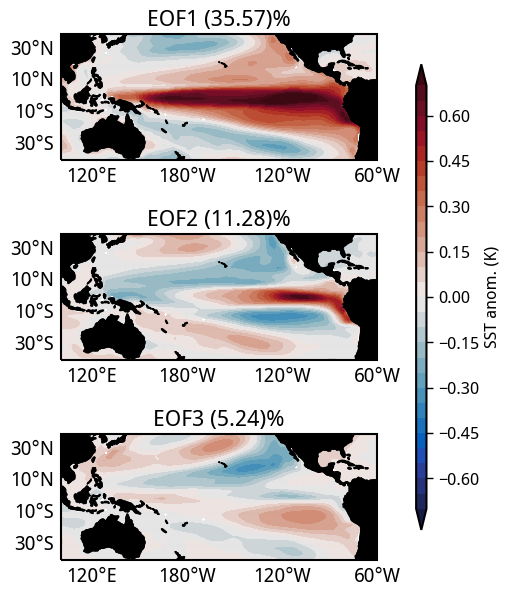

In [89]:
plot_maps(xx, yy, plot_list, title_list, label_list, cmap=cmocean.cm.balance, levels=np.arange(-0.7, 0.75, 0.05), cbar_label = 'SST anom. (K)', pval = [], nrows=3, ncols=1, figsize=(5,6), land_mask_list = [0, 1, 2], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=160))

In [90]:
pc1 = pcs_pic.isel(mode=0)/pcs_pic.isel(mode=0).std('time')
pc2 = pcs_pic.isel(mode=1)/pcs_pic.isel(mode=1).std('time')

In [91]:
e_index = (pc1 - pc2)/np.sqrt(2)
c_index = (pc1 + pc2)/np.sqrt(2)

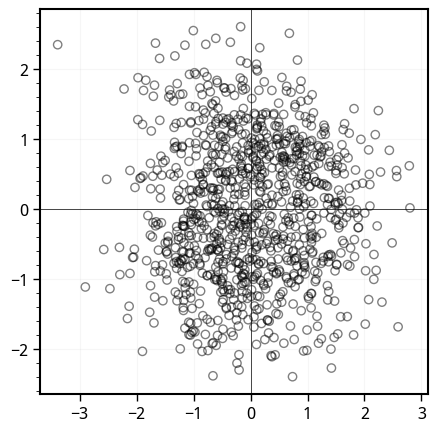

In [134]:

plt.figure(figsize=(5,5))
plt.scatter(pc1, pc2, marker='o', color='k', facecolor='None', alpha=0.5)
# plt.scatter(pc1[(e_index < -e_index.std('time') & (c_index >))], pc2[(e_index < -e_index.std('time'))], marker='o', color='tab:purple')
# plt.scatter(pc1[(e_index > e_index.std('time'))], pc2[(e_index > e_index.std('time'))], marker='o', color='maroon')
# plt.scatter(pc1[(c_index < -c_index.std('time'))], pc2[(c_index < -c_index.std('time'))], marker='o', color='tab:blue')
# plt.scatter(pc1[(c_index > c_index.std('time'))], pc2[(c_index > c_index.std('time'))], marker='o', color='tab:red')
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
plot_decorator()

In [95]:
ts_trans_ocean = ts_trans.where(~land_mask).squeeze()

In [ ]:
eof1_pic
for i in range(len(ts_trans_ocean.model)):
    solver = Eof(funcs.detrend_rolling_window(ts_trans_ocean.sel(lat = slice(-40, 40), lon = slice(100, 300)).isel(model=10).squeeze(), window_size=15).sel(time = slice('1900', '2093')))
eofs_pic = solver.eofs(neofs=3)
pcs_pic = solver.pcs(npcs=3)
variance_pic = solver.varianceFraction(neigs=3)

In [143]:
plot_list = [(eofs_pic.isel(mode=0)*pcs_pic.isel(mode=0).std('time')),
             (eofs_pic.isel(mode=1)*pcs_pic.isel(mode=1).std('time')),
             (eofs_pic.isel(mode=2)*pcs_pic.isel(mode=2).std('time')),
             ]

In [144]:
title_list = [
    f'EOF1 ({np.round(float(variance_pic.isel(mode=0)), 4)*100})%',
    f'EOF2 ({np.round(float(variance_pic.isel(mode=1)), 4)*100})%',
    f'EOF3 ({np.round(float(variance_pic.isel(mode=2)), 4)*100})%',
]

In [145]:
label_list = [
    '',
    '',
    '',
]

In [146]:
xx, yy = np.meshgrid(plot_list[0].lon, plot_list[0].lat)

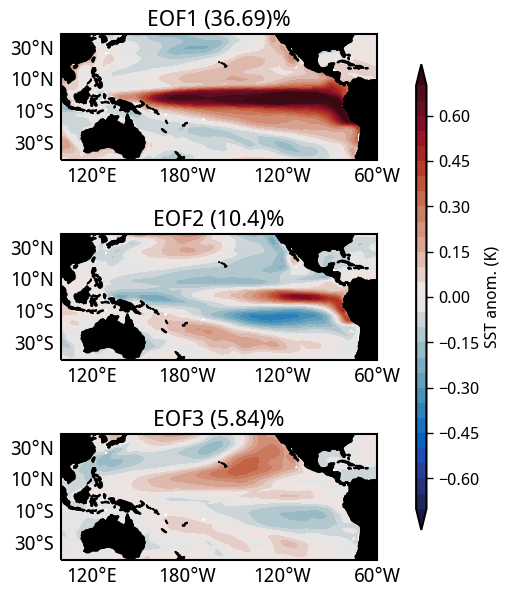

In [147]:
plot_maps(xx, yy, plot_list, title_list, label_list, cmap=cmocean.cm.balance, levels=np.arange(-0.7, 0.75, 0.05), cbar_label = 'SST anom. (K)', pval = [], nrows=3, ncols=1, figsize=(5,6), land_mask_list = [0, 1, 2], add_patch=False, add_patch_extra=False, cbar_orientation='vertical', hatch_type = 'insig', proj=ccrs.PlateCarree(central_longitude=160))

In [148]:
pc1 = pcs_pic.isel(mode=0)/pcs_pic.isel(mode=0).std('time')
pc2 = pcs_pic.isel(mode=1)/pcs_pic.isel(mode=1).std('time')

In [149]:
e_index = (pc1 - pc2)/np.sqrt(2)
c_index = (pc1 + pc2)/np.sqrt(2)

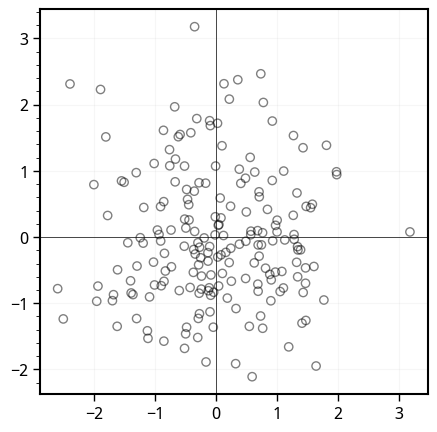

In [150]:

plt.figure(figsize=(5,5))
plt.scatter(pc1, pc2, marker='o', color='k', facecolor='None', alpha=0.5)
# plt.scatter(pc1[(e_index < -e_index.std('time') & (c_index >))], pc2[(e_index < -e_index.std('time'))], marker='o', color='tab:purple')
# plt.scatter(pc1[(e_index > e_index.std('time'))], pc2[(e_index > e_index.std('time'))], marker='o', color='maroon')
# plt.scatter(pc1[(c_index < -c_index.std('time'))], pc2[(c_index < -c_index.std('time'))], marker='o', color='tab:blue')
# plt.scatter(pc1[(c_index > c_index.std('time'))], pc2[(c_index > c_index.std('time'))], marker='o', color='tab:red')
plt.axhline(0.0, lw=0.5, color='k')
plt.axvline(0.0, lw=0.5, color='k')
plot_decorator()

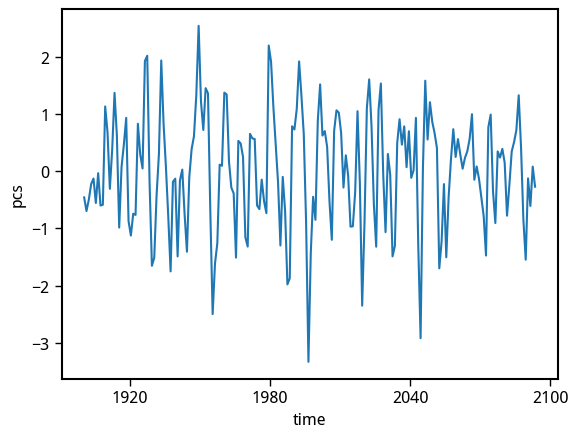

In [152]:
e_index.plot()

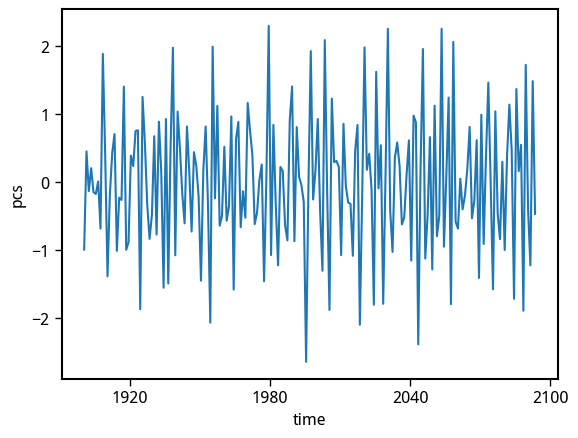

In [153]:
c_index.plot()

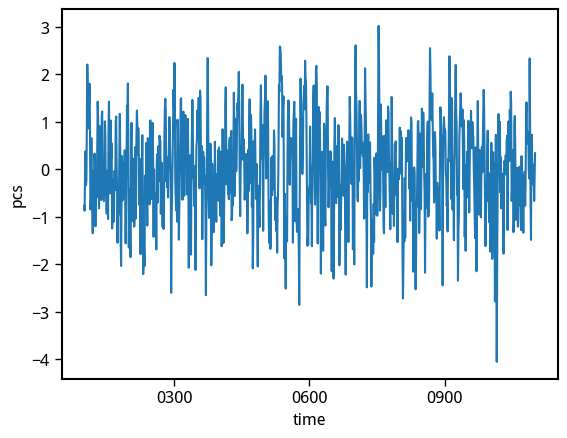

In [ ]:
e_index.plot()

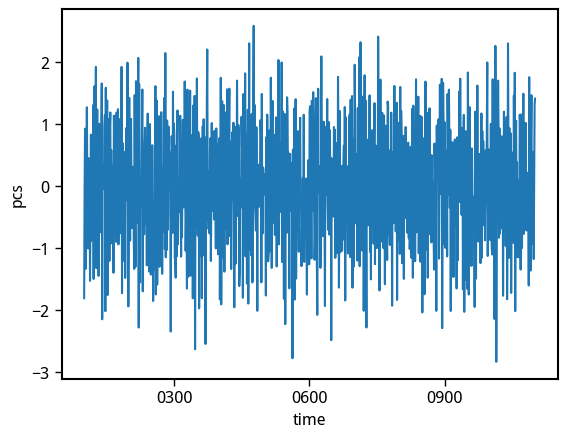

In [138]:
c_index.plot()

## power spectrum

In [115]:
from scipy.signal import cwt, morlet2

In [116]:
from scipy.signal import welch

def compute_psd(index, fs=1, nperseg=None, plot=True, ar1_sig=True, alpha=0.95):
    """
    Compute Welch Power Spectral Density (PSD) for a climate index time series
    and optionally compare with a red-noise (AR1) significance spectrum.
    
    Parameters
    ----------
    index : array-like
        1D time series (e.g., Niño3.4 annual index, already detrended if desired).
    fs : float, optional
        Sampling frequency (default=1 for annual data, 12 for monthly).
    nperseg : int, optional
        Segment length for Welch method (default = len(index)//2).
    plot : bool, optional
        If True, generates a log-log PSD plot.
    ar1_sig : bool, optional
        If True, overlays the AR(1) red-noise significance spectrum.
    alpha : float, optional
        Confidence level for AR1 significance (default=0.95).
    
    Returns
    -------
    periods : ndarray
        Periods (inverse of frequency) in same units as 1/fs.
    psd : ndarray
        Power spectral density values corresponding to periods.
    psd_red : ndarray or None
        Red-noise (AR1) spectrum corresponding to periods if ar1_sig=True, else None.
    """
    index = np.asarray(index).flatten()
    N = len(index)
    
    if nperseg is None:
        nperseg = N // 2
    
    # Welch PSD
    f, Pxx = welch(index, fs=fs, window="hann", nperseg=nperseg, scaling="density")
    mask = f > 0
    periods = 1 / f[mask]
    psd = Pxx[mask]
    
    psd_red = None
    if ar1_sig:
        # Estimate lag-1 autocorrelation
        r1 = np.corrcoef(index[:-1], index[1:])[0,1]
        # Red-noise spectrum formula for AR(1) process
        psd_red = (1 - r1**2) / (1 + r1**2 - 2*r1*np.cos(2*np.pi*f[mask]/fs))
        psd_red *= np.var(index)  # scale by variance of the time series
        # Adjust for confidence level (chi-square)
        from scipy.stats import chi2
        chi2_val = chi2.ppf(alpha, df=2)
        psd_red *= chi2_val / 2  # df=2 for one-sided PSD
    
    return periods, psd, psd_red

3.2051282051282053

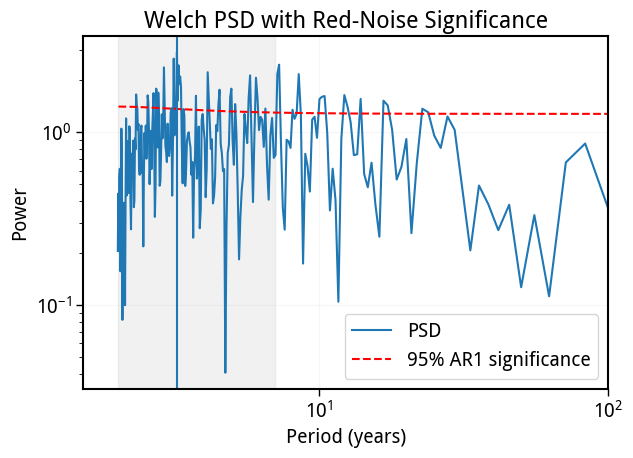

In [121]:
periods, psd, psd_red = compute_psd(nino34_pic.dropna('time'))
plt.loglog(periods, psd, label='PSD')
plt.loglog(periods, psd_red, '--r', label=f'{int(0.95*100)}% AR1 significance')
plt.axvline(periods[np.argmax(psd)])
plt.axvspan(2, 7, color='tab:gray', alpha=0.1)
plt.xlabel("Period (years)")
plt.ylabel("Power")
plt.title("Welch PSD with Red-Noise Significance")
plot_decorator()
plt.legend()
plt.tight_layout()
plt.xlim(0, 100)
periods[np.argmax(psd)]

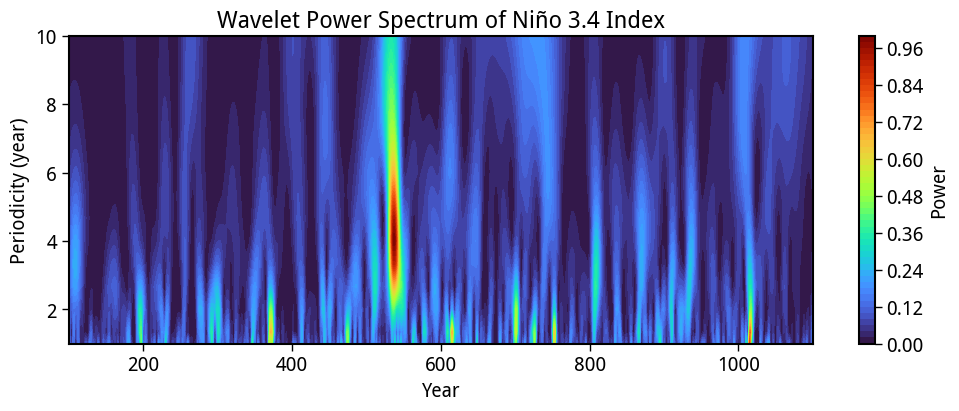

In [62]:
# Define wavelet parameters
widths = np.arange(1, 64)  # Scales: controls the range of periodicities
f0 = 1.5  # Central frequency of the Morlet wavelet
dt=1

# Perform CWT using Morlet wavelet
wave = cwt(nino34_pic, lambda M, s: morlet2(M, s, w=f0), widths)
power = np.abs(wave)**2  # Power spectrum

# Convert scales to approximate period (period ~ scale)
period = widths * dt / f0

# Plotting the wavelet power spectrum
plt.figure(figsize=(12, 4))
plt.contourf(nino34_pic.time.dt.year, period, power/power.max(), levels=50, vmin=0, vmax=1, cmap='turbo')
# plt.yscale('log')
# plt.gca().invert_yaxis()
plt.colorbar(label='Power')
plt.xlabel('Year')
plt.ylabel('Periodicity (year)')
plt.title('Wavelet Power Spectrum of Niño 3.4 Index')
plt.ylim(1, 10)
plt.show()

In [260]:
power_baseline = (power/power.max()).mean(axis=1)
power_baseline.shape

(63,)

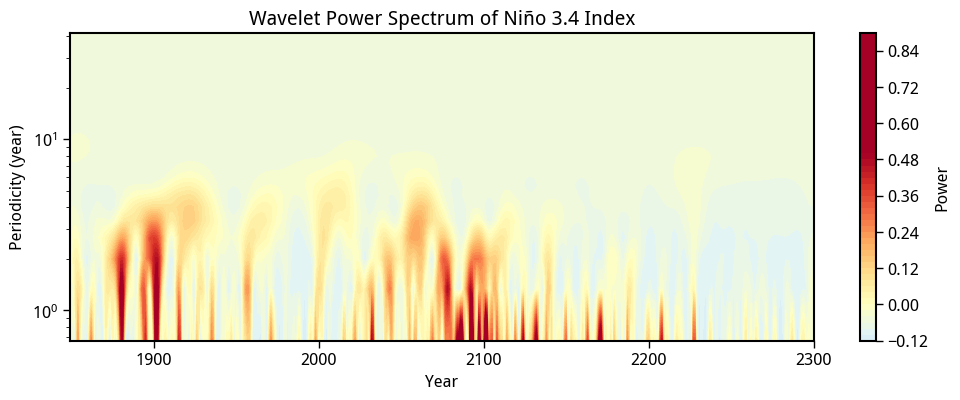

In [266]:
# Define wavelet parameters
widths = np.arange(1, 64)  # Scales: controls the range of periodicities
f0 = 1.5  # Central frequency of the Morlet wavelet
dt=1

# Perform CWT using Morlet wavelet
wave = cwt(nino34_trans.isel(model=0), lambda M, s: morlet2(M, s, w=f0), widths)
power = np.abs(wave)**2  # Power spectrum

# Convert scales to approximate period (period ~ scale)
period = widths * dt / f0

# Plotting the wavelet power spectrum
plt.figure(figsize=(12, 4))
plt.contourf(nino34_trans.isel(model=0).time.dt.year, period, (power/power.max() - np.expand_dims(power_baseline, axis=1)), levels=50, vmin=-0.5, vmax=0.5,  cmap='RdYlBu_r')
plt.yscale('log')
# plt.gca().invert_yaxis()
plt.colorbar(label='Power')
plt.xlabel('Year')
plt.ylabel('Periodicity (year)')
plt.title('Wavelet Power Spectrum of Niño 3.4 Index')
# plt.ylim(1, 10)
plt.show()

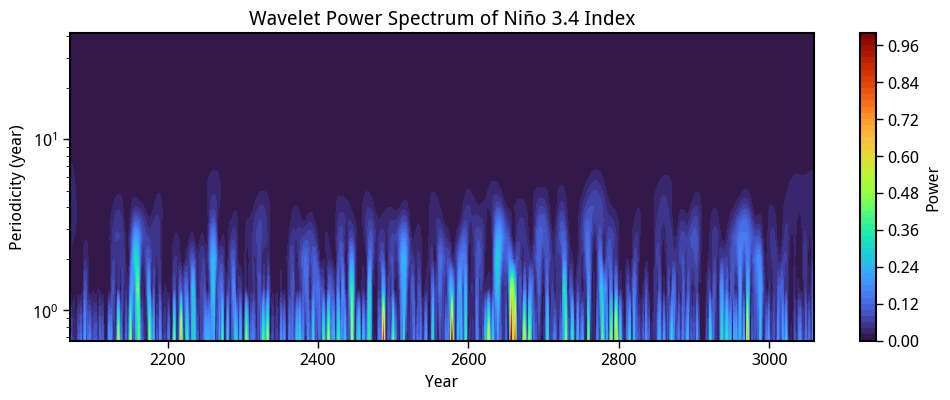

In [276]:
# Define wavelet parameters
widths = np.arange(1, 64)  # Scales: controls the range of periodicities
f0 = 1.5  # Central frequency of the Morlet wavelet
dt=1

# Perform CWT using Morlet wavelet
wave = cwt(nino34_stable.sel(model='B2060').sel(time = slice('2070', '3060')), lambda M, s: morlet2(M, s, w=f0), widths)
power = np.abs(wave)**2  # Power spectrum

# Convert scales to approximate period (period ~ scale)
period = widths * dt / f0

# Plotting the wavelet power spectrum
plt.figure(figsize=(12, 4))
plt.contourf(nino34_stable.sel(model='B2060').sel(time = slice('2070', '3060')).time.dt.year, period, (power/power.max()), levels=50,  cmap='turbo')
# plt.contourf(nino34_stable.sel(model='B2060').time.dt.year, period, (power/power.max() - np.expand_dims(power_baseline, axis=1)), levels=50, vmin=-0.5, vmax=0.5,  cmap='RdYlBu_r')
plt.yscale('log')
# plt.gca().invert_yaxis()
plt.colorbar(label='Power')
plt.xlabel('Year')
plt.ylabel('Periodicity (year)')
plt.title('Wavelet Power Spectrum of Niño 3.4 Index')
# plt.ylim(1, 10)
plt.show()

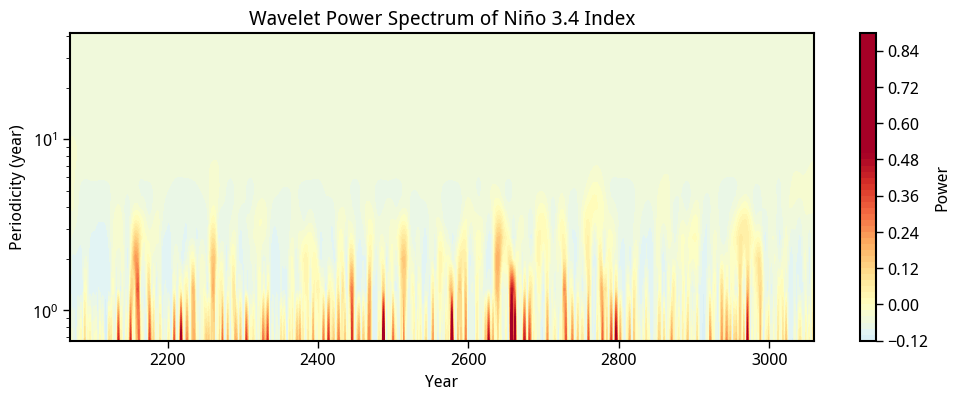

In [277]:
# Define wavelet parameters
widths = np.arange(1, 64)  # Scales: controls the range of periodicities
f0 = 1.5  # Central frequency of the Morlet wavelet
dt=1

# Perform CWT using Morlet wavelet
wave = cwt(nino34_stable.sel(model='B2060').sel(time = slice('2070', '3060')), lambda M, s: morlet2(M, s, w=f0), widths)
power = np.abs(wave)**2  # Power spectrum

# Convert scales to approximate period (period ~ scale)
period = widths * dt / f0

# Plotting the wavelet power spectrum
plt.figure(figsize=(12, 4))
# plt.contourf(nino34_stable.sel(model='B2060').sel(time = slice('2070', '3060')).time.dt.year, period, (power/power.max()), levels=50,  cmap='turbo')
plt.contourf(nino34_stable.sel(model='B2060').time.dt.year.sel(time = slice('2070', '3060')).time.dt.year, period, (power/power.max() - np.expand_dims(power_baseline, axis=1)), levels=50, vmin=-0.5, vmax=0.5,  cmap='RdYlBu_r')
plt.yscale('log')
# plt.gca().invert_yaxis()
plt.colorbar(label='Power')
plt.xlabel('Year')
plt.ylabel('Periodicity (year)')
plt.title('Wavelet Power Spectrum of Niño 3.4 Index')
# plt.ylim(1, 10)
plt.show()

In [171]:
solver = Eof(ts_trans.sel(lat = slice(-20, 20), lon = slice(120, 270)).isel(model=0))

In [172]:
ts_stable

<xarray.DataArray 'ts' (model: 7, time: 1031, lat: 120, lon: 240)>
[207849600 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 0.0 1.5 3.0 4.5 6.0 ... 352.5 354.0 355.5 357.0 358.5
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
  * time     (time) object 2029-06-01 00:00:00 ... 3059-06-01 00:00:00
  * model    (model) object 'B2045' 'B2030' 'B2060' ... 'B2040' 'B2035' 'B2050'

In [173]:
solver_stable = Eof(ts_stable.sel(lat = slice(-20, 20), lon = slice(120, 270)).sel(model='B2060').isel(time = slice(-300, None)))

In [174]:
eofs = solver.eofs(neofs=3)
pcs = solver.pcs(npcs=3)

In [175]:
eofs = solver.eofs(neofs=3)
pcs = solver.pcs(npcs=3)

In [176]:
variance = solver.varianceFraction(neigs=3)

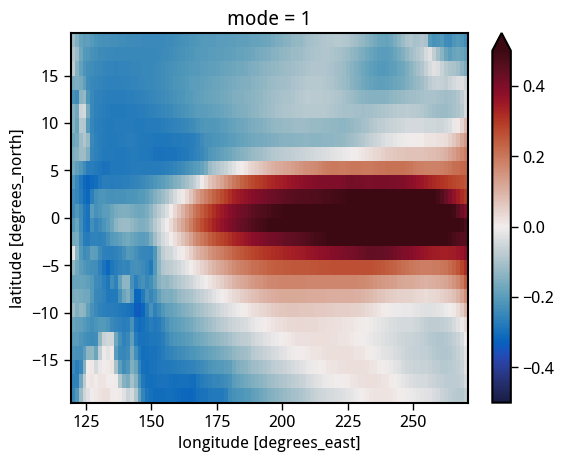

In [177]:
(eofs.isel(mode=1)*pcs.isel(mode=1).std('time')).plot(cmap=cmocean.cm.balance, vmin=-0.5)

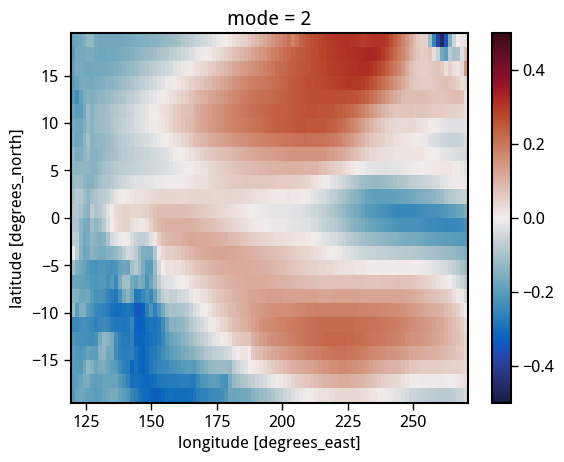

In [ ]:
(eofs.isel(mode=2)*pcs.isel(mode=2).std('time')).plot(cmap=cmocean.cm.balance, vmin=-0.5)


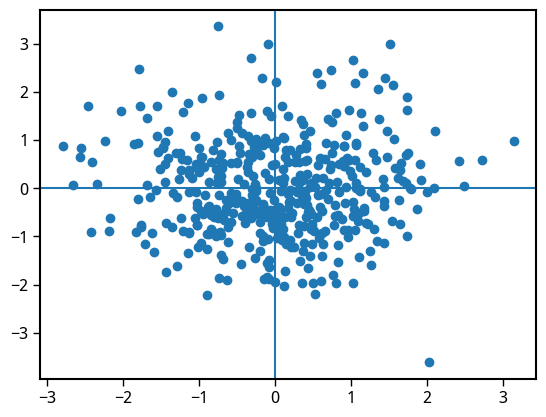

In [ ]:
pc1 = pcs.isel(mode=1)/pcs.isel(mode=1).std('time')
pc2 = pcs.isel(mode=2)/pcs.isel(mode=2).std('time')
plt.scatter(pc1, pc2)
plt.axhline(0.0)
plt.axvline(0.0)

In [ ]:
e_index= (pc1 - pc2)/np.sqrt(2)

In [ ]:
c_index= (pc1 + pc2)/np.sqrt(2)

In [ ]:
e_index